<a id="toc"></a>
<p><center style="color:#4caba4; font-family: 'Dancing Script', cursive; font-size:25px;">Thanks for visiting my notebook </center></p>

<div style="background-color:pink; padding: 5px;">
<div class="alert alert-block alert-secondary" style="font-size:15px; font-family:verdana;">  Feel free to customize or fork the notebook to suit your needs.<br>
If you find it informative, please upvote it so that it can reach others and also I get motivated to build more interesting notebooks.</div></div>

<div>

 <h2 align="left"><font color=#E1B12D>About the Session</font></h2>

The session is all about learning '**Representation Learning**' on a nice level in just one go.

<div>

 <h2 align="left"><font color=#E1B12D>Table of Contents</font></h2></div>
 
<a id="toc"></a>
- [1 Basic Operations on Images](#1)
- [2 Analysis using PCA](#2)
- [3 Analysis using LDA](#3)
- [4 Histogram using LBP and Sobels Filter](#4)
- [4.1 Local Binary Pattern](#4.1)
- [4.2 Sobels](#4.2)
- [4.3 Histogram of Gradients](#4.3)
- [5 Simple CNN Implementation](#5)
- [6 Audio Processing using LIbrosa](#6)
- [7 Text Kernalization and TTR ](#7)
- [8 Feature Extraction using NLTK ](#8)

<a id="1"></a>
## <b><span style='color:#E1B12D'>Basic operations on Images</span></b> 

In [1]:
#Importing libraries
from PIL import Image
import urllib.request
import numpy as np 
import cv2
import matplotlib.pyplot as plt

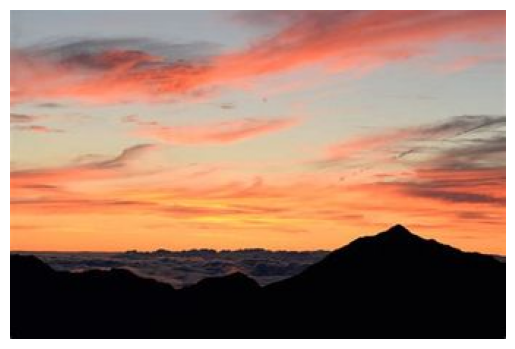

In [2]:
# Importing an image from a link
resp = urllib.request.urlopen("https://imgs.search.brave.com/kxnZO19mwbP1CoNL7XHiPlHFg3j0vEDjnkaU1DJHr10/rs:fit:713:225:1/g:ce/aHR0cHM6Ly90c2Ux/Lm1tLmJpbmcubmV0/L3RoP2lkPU9JUC5U/VURlNzQtX09SNk8z/UDRWLTNfRllRSGFF/NyZwaWQ9QXBp")
image = np.asarray(bytearray(resp.read()), dtype="uint8")
pic = cv2.imdecode(image, cv2.IMREAD_COLOR)

pic = cv2.cvtColor(pic, cv2.COLOR_BGR2RGB)   # converting the color space from BGR (used by OpenCV) to RGB (used by matplotlib for displaying images).

# Displaying the image
plt.imshow(pic)
plt.axis('off')
plt.show()


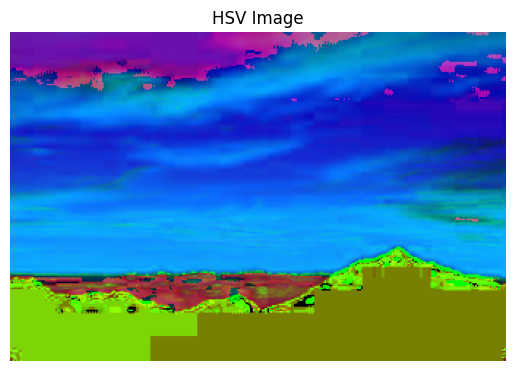

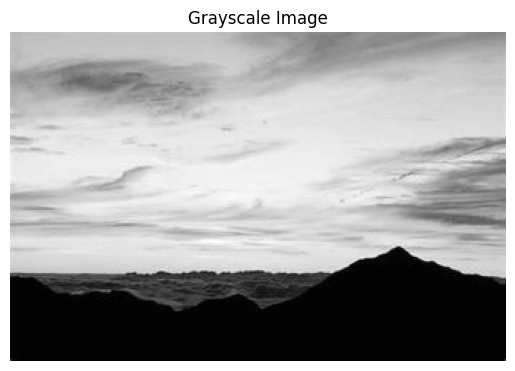

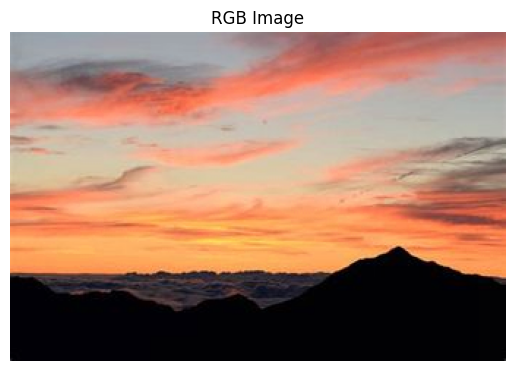

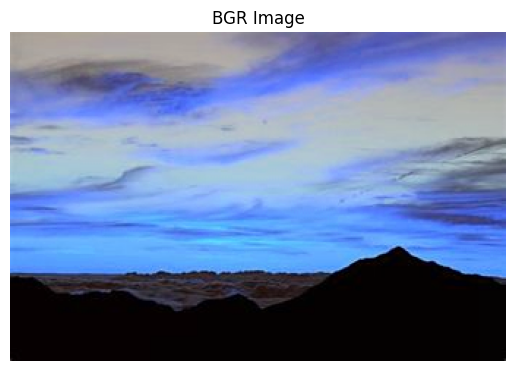

In [3]:
# Converting Image to various colorspaces
gray_image = cv2.cvtColor(pic, cv2.COLOR_RGB2GRAY)  # GrayScale
hsv_image = cv2.cvtColor(pic, cv2.COLOR_RGB2HSV)  # Hue, Saturation, Value
rgb_image = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB)  # Red, Green, Blue
bgr_image = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2BGR)  # Blue, Green, Red

# Images in various colorspaces
plt.imshow(hsv_image)
plt.axis('off')
plt.title('HSV Image')
plt.show()

plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.title('Grayscale Image')
plt.show()

plt.imshow(rgb_image)
plt.axis('off')
plt.title('RGB Image')
plt.show()

plt.imshow(bgr_image)
plt.axis('off')
plt.title('BGR Image')
plt.show()

Mean Filter



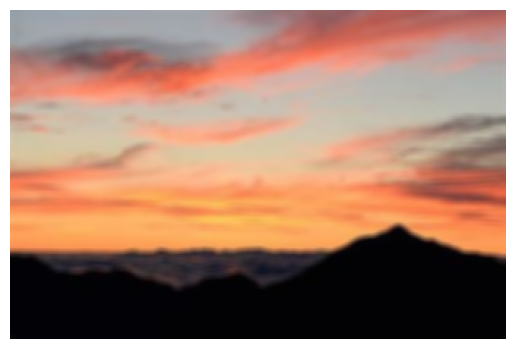

Gaussian Filter



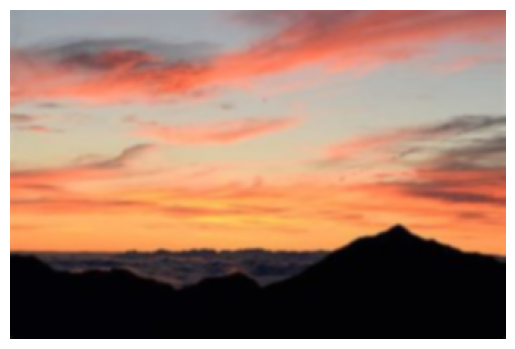

Median Filter



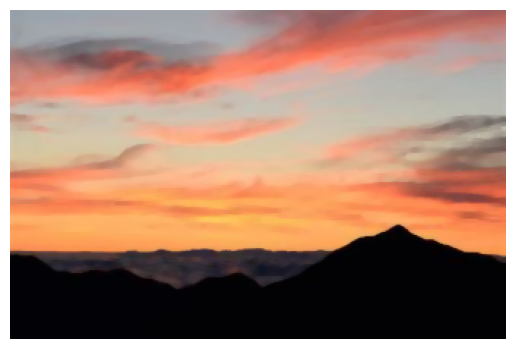

Laplacian Filter



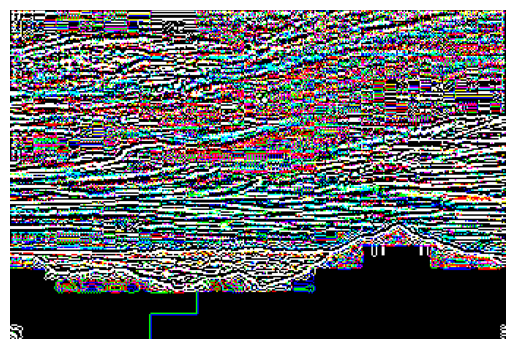

Laplacian Filtered Image



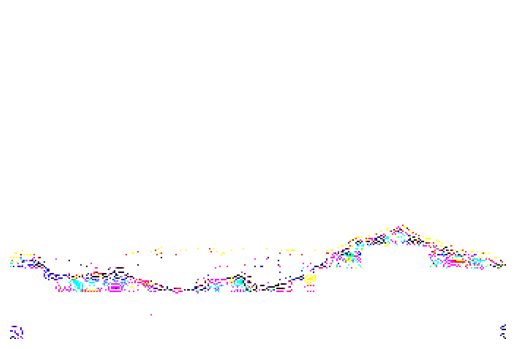

In [4]:
# Applying various filters to the image
blur = cv2.blur(pic, (5, 5))  # Blur by filter size 5
Gblur = cv2.GaussianBlur(pic, (5, 5), 0)  # Gaussian Blur by filter size 5
Mblur = cv2.medianBlur(pic, 5)  # Median Blur by filter size 5
laplacian = cv2.Laplacian(pic, cv2.CV_64F)  # Laplacian Filter

# Displaying Images after Filters
print("Mean Filter\n")
plt.imshow(blur)
plt.axis('off')
plt.show()
print("Gaussian Filter\n")
plt.imshow(Gblur)
plt.axis('off')
plt.show()
print("Median Filter\n")
plt.imshow(Mblur)
plt.axis('off')
plt.show()
print("Laplacian Filter\n")
plt.imshow(laplacian, cmap='gray')
plt.axis('off')
plt.show()
print("Laplacian Filtered Image\n")
laplacian_filtered_img = laplacian + pic
plt.imshow(laplacian_filtered_img)
plt.axis('off')
plt.show()



<a id="toc"></a>

<a href="#toc" style="background-color: #E1B12D; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="2"></a>
## <b><span style='color:#E1B12D'>Analysis using PCA</span></b> 

In [5]:
#Importing Libraries
import numpy as np
import pandas as pd
import seaborn as sb
data=sb.load_dataset("iris")   #Iris Dataset
y=data['species']              #Target Variable
data=data[["sepal_length","sepal_width","petal_length","petal_width"]]
data.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
#Normalising Data : Xi=(X-Mean)/std

mean=np.mean(data,axis=0)
scale_std=np.std(data-mean,axis=0)
data=((data -mean) / scale_std)

data.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [7]:
#Finding covariance matrix

features=data.T
features=features.astype(dtype="float")
covr_mat=np.cov(features)
covr_mat      #Covariance matrix

array([[ 1.00671141, -0.11835884,  0.87760447,  0.82343066],
       [-0.11835884,  1.00671141, -0.43131554, -0.36858315],
       [ 0.87760447, -0.43131554,  1.00671141,  0.96932762],
       [ 0.82343066, -0.36858315,  0.96932762,  1.00671141]])

In [8]:
#Finding Eigenvalues and eigenvectors of covariance matrix

values, vectors = np.linalg.eig(covr_mat)
print(values)
print(vectors)

[2.93808505 0.9201649  0.14774182 0.02085386]
[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [9]:
#Calculating Explained Covariances

for i in range(len(values)):
   print(values[i] / np.sum(values),",")
   
#Since first two account for about 96% of covariance these are the two PCs

0.7296244541329988 ,
0.22850761786701748 ,
0.036689218892828675 ,
0.005178709107155041 ,


In [10]:
#Principal Components

projected_1 = data.dot(vectors.T[0])
projected_2 = data.dot(vectors.T[1])
res = pd.DataFrame(projected_1, columns=["PC1"])
res["PC2"] = projected_2
res["Y"] = y
res.head()

,PC1,PC2,Y
0,-2.264703,-0.480027,setosa
1,-2.080961,0.674134,setosa
2,-2.364229,0.341908,setosa
3,-2.299384,0.597395,setosa
4,-2.389842,-0.646835,setosa


<Axes: xlabel='PC1', ylabel='PC2'>

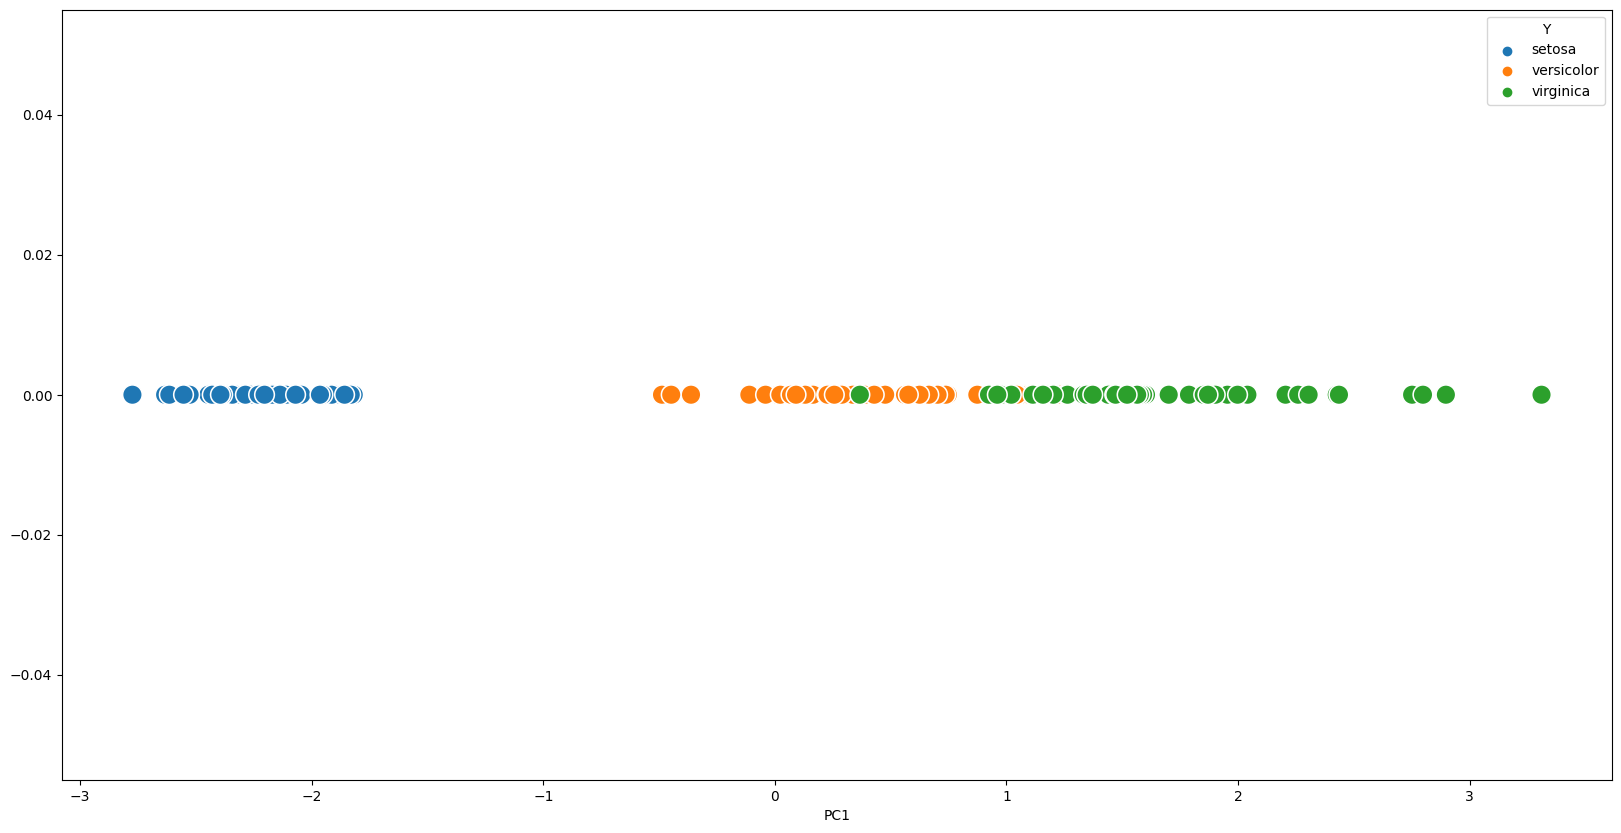

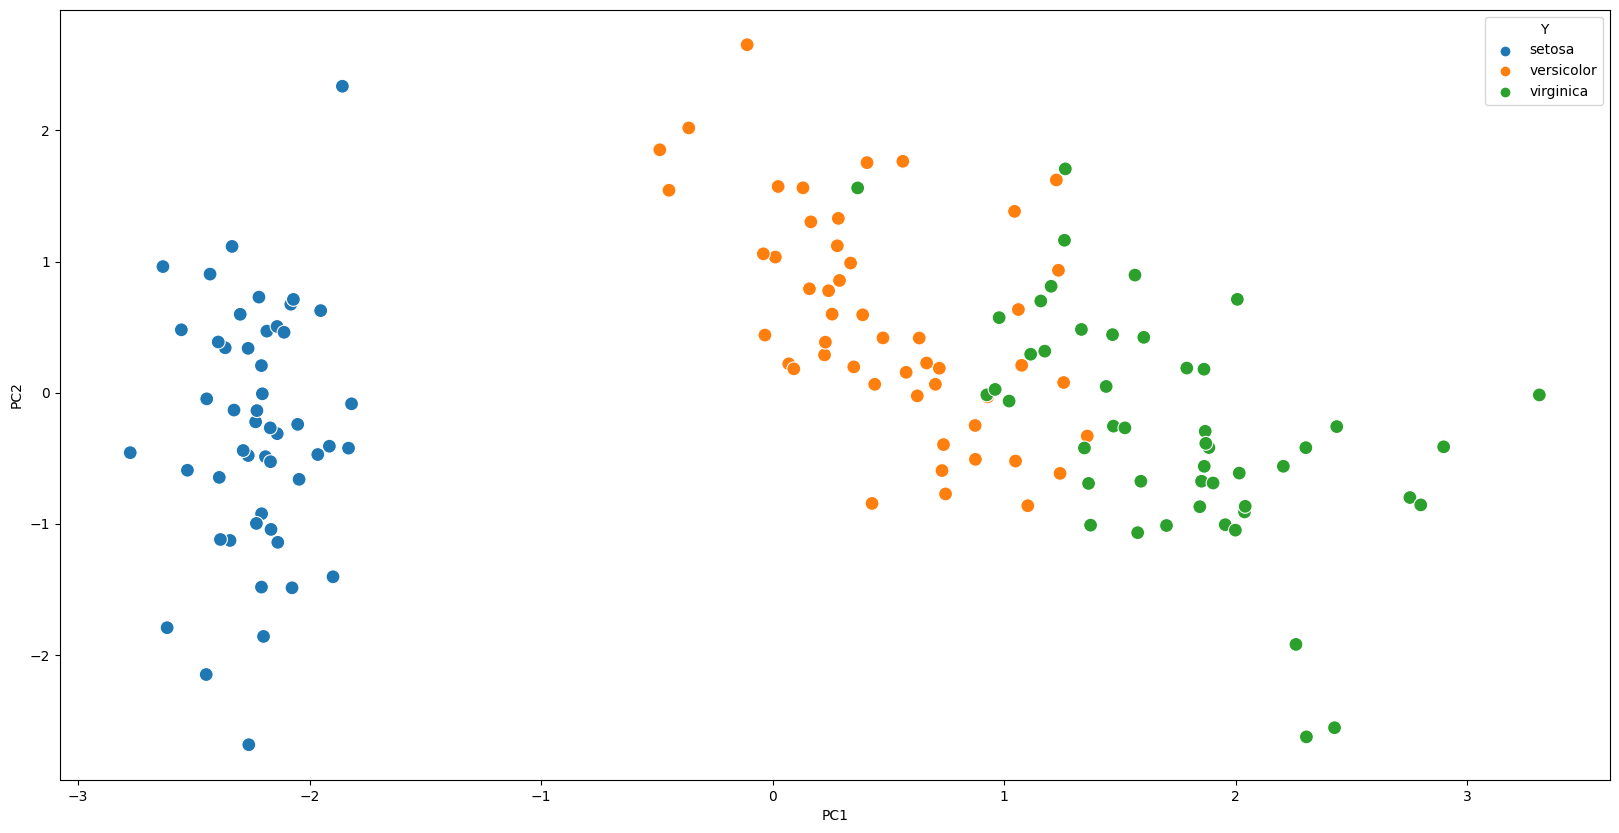

In [11]:
#Plotting data in 1D and 2D

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
sb.scatterplot(x=res["PC1"],y= [0] * len(res), hue=res["Y"], s=200)
plt.figure(figsize=(20, 10))
sb.scatterplot(x=res["PC1"],y=res["PC2"], hue=res["Y"], s=100)

<a id="toc"></a>

<a href="#toc" style="background-color: #E1B12D; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="3"></a>
## <b><span style='color:#E1B12D'>Analysis using LDA</span></b> 

In [12]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [13]:
#Dataset
data=sb.load_dataset("iris")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
#Data and Target 
X = data.iloc[:,0:4]
Y = data.iloc[:,4]

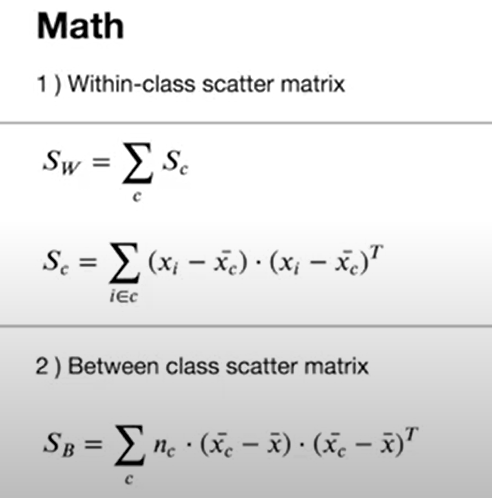

In [15]:
#No of classes

unique_v = Y.unique()
number_unique = len(unique_v) #No of categories

In [16]:
#Calculating within class and between class Scatter matrices
#Then finding eigenvectors and eigenvalues

S_W = np.zeros((4,4))  #Scatter Within classes
S_B = np.zeros((4,4))  #Scatter Between classes
mean_total = X.mean().to_numpy() #Mean of complete data
for i in range(len(unique_v)):
   class_values = X[Y==unique_v[i]]
   class_mean = class_values.mean().to_numpy()    #Mean of particular class

   S_W += (class_values-class_mean).T.dot(class_values-class_mean)  #Formula for calculating SW
   n_c = len(class_values)
   mean_diff = (class_mean - mean_total).reshape(4, 1)
   S_B += n_c * (mean_diff).dot(mean_diff.T)   #Formula for calculating SW

final_mat = np.linalg.inv(S_W).dot(S_B)
w, v = np.linalg.eig(final_mat)               #Calculating eigenvalues and eigenvectors
index = np.argsort(abs(w))[::-1]                   #Sorting eigenvectors on basis of eigenvectors
v = v[index]
w=w[index]
new_lda = v[0:2]
new_lda=np.dot(X, new_lda.T)
new_lda

array([[-0.07559514+0.j        , -4.33729117+0.28229239j],
       [-0.03058079+0.j        , -3.96674515+0.28229239j],
       [-0.05337945+0.j        , -3.98716931+0.25876802j],
       [ 0.09462918+0.j        , -3.92920232+0.30581675j],
       [-0.05537415+0.j        , -4.35733185+0.28229239j],
       [ 0.17537266+0.j        , -4.78608257+0.30581675j],
       [ 0.0926696 +0.j        , -4.10518548+0.25876802j],
       [ 0.00917287+0.j        , -4.25966696+0.30581675j],
       [ 0.07444331+0.j        , -3.71498225+0.28229239j],
       [-0.03123399+0.j        , -4.02540621+0.32934112j],
       [-0.07628345+0.j        , -4.5901316 +0.30581675j],
       [ 0.11416186+0.j        , -4.20208343+0.32934112j],
       [-0.07294724+0.j        , -3.90846757+0.30581675j],
       [-0.15829821+0.j        , -3.65639408+0.23524366j],
       [-0.35146165+0.j        , -4.8616246 +0.23524366j],
       [-0.01699712+0.j        , -5.15593452+0.25876802j],
       [-0.07758984+0.j        , -4.70745371+0.21171929j

/opt/conda/lib/python3.10/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


<Axes: >

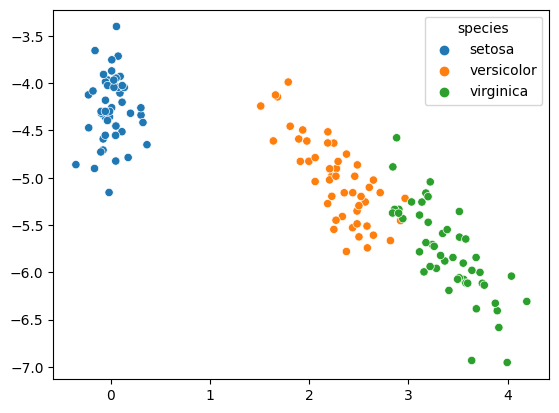

In [17]:
#Plotting The Graph

sb.scatterplot(x=new_lda[:,0],y=new_lda[:,1],hue=Y)

<a id="toc"></a>

<a href="#toc" style="background-color: #E1B12D; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4"></a>
## <b><span style='color:#E1B12D'>Histogram using LBP and Sobels Filter</span></b> 

Importing Image and Libraries

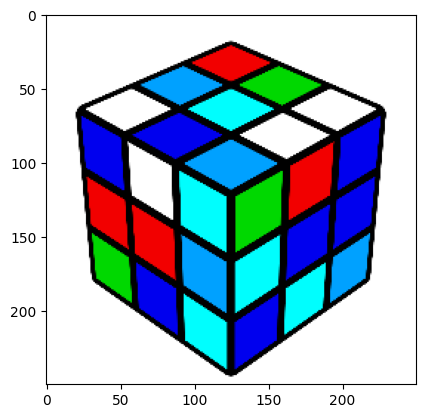

In [18]:
req = urllib.request.urlopen('https://upload.wikimedia.org/wikipedia/commons/thumb/4/44/Scramble.svg/1200px-Scramble.svg.png')
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img = cv2.imdecode(arr, -1)
img = cv2.resize(img,(250,250))
plt.imshow(img)
plt.show()

Converting Image to greyscale

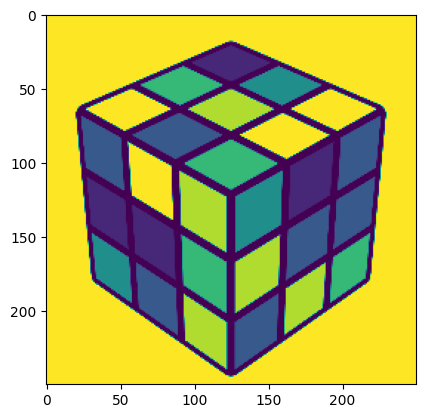

In [19]:
img=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img)
plt.show()

Creating Histogram of Pixel Intensities

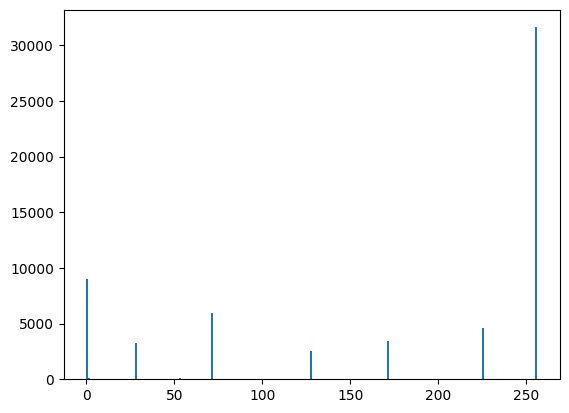

In [20]:
plt.hist(img.ravel(),256,[0,256])
plt.show()

<a id="4.1"></a>
## <b><span style='color:#E1B12D'>Local Binary Pattern (LBP)</span></b> 

Padding Image with 0 intensity to be able to apply filter on boundries

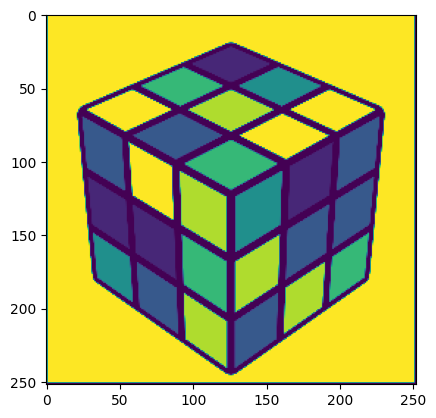

In [21]:
img= np.pad(img, [(1, ), (1, )], mode='constant')
plt.imshow(img)
plt.show()

Function to check if boundary pixel is higher intensity or not

In [22]:
def pixel_val(img,center,x,y):
  if img[x][y]>=center:
    return 1
  else:
    return 0

Function which will be later used by loop to apply filter on each pixel

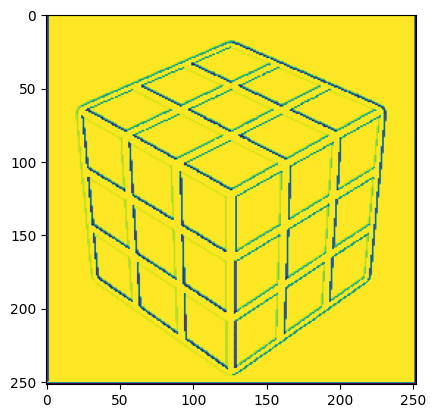

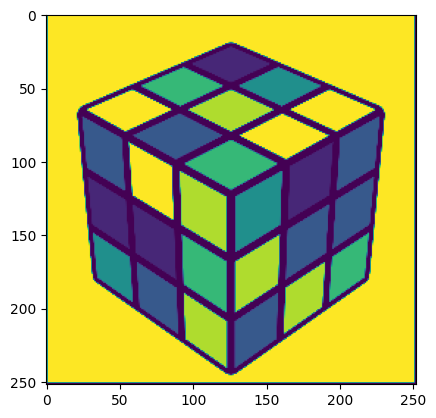

In [23]:
img_lbp=img.copy()
def lbp_calculated_pixel(img, x, y):
   
    center = img[x][y]
   
    val_ar = []
      
    # top_left
    val_ar.append(pixel_val(img, center, x-1, y-1))
      
    # top
    val_ar.append(pixel_val(img, center, x-1, y))
      
    # top_right
    val_ar.append(pixel_val(img, center, x-1, y + 1))
      
    # right
    val_ar.append(pixel_val(img, center, x, y + 1))
      
    # bottom_right
    val_ar.append(pixel_val(img, center, x + 1, y + 1))
      
    # bottom
    val_ar.append(pixel_val(img, center, x + 1, y))
      
    # bottom_left
    val_ar.append(pixel_val(img, center, x + 1, y-1))
      
    # left
    val_ar.append(pixel_val(img, center, x, y-1))
       
    # Now, we need to convert binary
    # values to decimal
    power_val = [1, 2, 4, 8, 16, 32, 64, 128]
   
    val = 0
      
    for i in range(len(val_ar)):
        val += val_ar[i] * power_val[i]
          
    return val
   


for i in range(1, 250):
    for j in range(1, 250):
        img_lbp[i, j] = lbp_calculated_pixel(img, i, j)
plt.imshow(img_lbp)
plt.show()
plt.imshow(img)
plt.show()

<a id="4.2"></a>
## <b><span style='color:#E1B12D'>Sobels</span></b> 

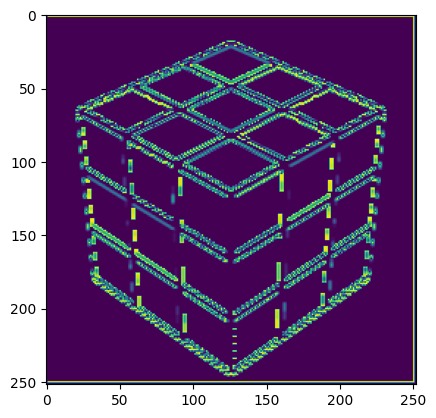

In [24]:
img_sob_hor=img.copy()
img_sob_ver=img.copy()
def sobels_vertical(img, x, y):
   
    center = img[x][y]
   
    val_ar = []
      
    # top_left
    val_ar.append(img[x-1, y-1])
      
    # top
    val_ar.append(img[ x-1, y])
      
    # top_right
    val_ar.append(img[ x-1, y + 1])
      
    # right
    val_ar.append(img[ x, y + 1])
      
    # bottom_right
    val_ar.append(img[ x + 1, y + 1])
      
    # bottom
    val_ar.append(img[ x + 1, y])
      
    # bottom_left
    val_ar.append(img[x + 1, y-1])
      
    # left
    val_ar.append(img[x, y-1])
       
    # Now, we need to convert binary
    # values to decimal
    power_val = [-1, -2, -1, 0, 1, 2, 1, 0]
   
    val = 0
      
    for i in range(len(val_ar)):
        val += val_ar[i] * power_val[i]
          
    return val
   


for i in range(1, 250):
    for j in range(1, 250):
        img_sob_ver[i, j] = sobels_vertical(img, i, j)
plt.imshow(img_sob_ver)
plt.show()

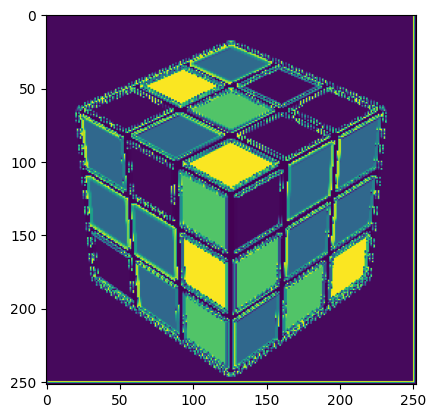

In [25]:
def sobels_horz(img, x, y):
   
    center = img[x][y]
   
    val_ar = []
      
    # top_left
    val_ar.append(img[x-1, y-1])
      
    # top
    val_ar.append(img[ x-1, y])
      
    # top_right
    val_ar.append(img[ x-1, y + 1])
      
    # right
    val_ar.append(img[ x, y + 1])
      
    # bottom_right
    val_ar.append(img[ x + 1, y + 1])
      
    # bottom
    val_ar.append(img[ x + 1, y])
      
    # bottom_left
    val_ar.append(img[x + 1, y-1])
      
    # left
    val_ar.append(img[x, y-1])
       
    # Now, we need to convert binary
    # values to decimal
    power_val = [1, 0, -1, -2, -1, 0, -1, -2]
   
    val = 0
      
    for i in range(len(val_ar)):
        val += val_ar[i] * power_val[i]
          
    return val
   


for i in range(1, 250):
    for j in range(1, 250):
        img_sob_hor[i, j] = sobels_horz(img, i, j)
plt.imshow(img_sob_hor)
plt.show()

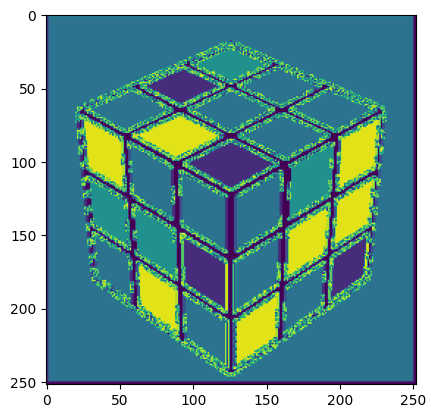

In [26]:
gradient_magnitude = np.sqrt(np.square(img_sob_hor) + np.square(img_sob_ver))
gradient_magnitude *= 255.0 / gradient_magnitude.max()

plt.imshow(gradient_magnitude)
plt.show()

<a id="toc"></a>

<a href="#toc" style="background-color: #E1B12D; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4.3"></a>
## <b><span style='color:#E1B12D'>Extracting HOG features of an image</span></b> 

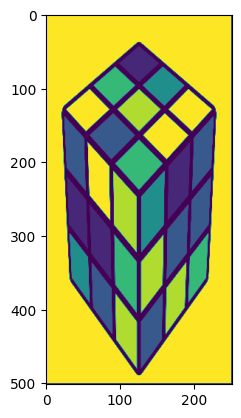

In [27]:
req = urllib.request.urlopen('https://upload.wikimedia.org/wikipedia/commons/thumb/4/44/Scramble.svg/1200px-Scramble.svg.png')
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img = cv2.imdecode(arr, -1)
img = cv2.resize(img,(250,500))   #Resizing in ratio 1:2
img=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img= np.pad(img, [(1, ), (1, )], mode='constant')
plt.imshow(img)
plt.show()

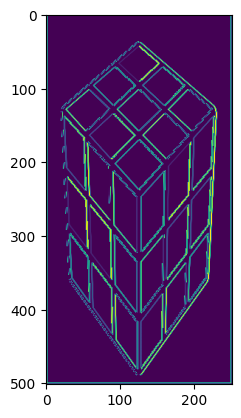

In [28]:
img_hog_x=img.copy()
img_hog_y=img.copy()

#Vertical gradient calculation

def hog_x(img, x, y):
   
    center = img[x][y]
   
    val_ar = []
      
    # right
    val_ar.append(img[ x, y + 1])
      
    # left
    val_ar.append(img[x, y-1])
       
    # Now, we need to convert binary
    # values to decimal
    power_val = [1,-1]
   
    val = 0
      
    for i in range(len(val_ar)):
        val += val_ar[i] * power_val[i]
          
    return val
   


for i in range(1, 500):
    for j in range(1, 250):
        img_hog_x[i, j] = hog_x(img, i, j)
plt.imshow(img_hog_x)
plt.show()

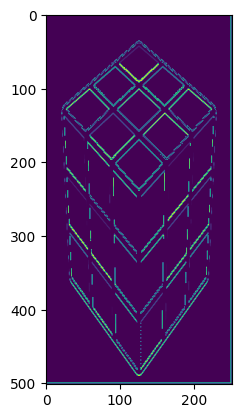

In [29]:
#Horiuzontal Gradient Calulation

def hog_y(img, x, y):
   
    center = img[x][y]
   
    val_ar = []
      
      
    # top
    val_ar.append(img[ x-1, y])
      
    # bottom
    val_ar.append(img[ x + 1, y])
       
    # Now, we need to convert binary
    # values to decimal
    power_val = [-1,1]
   
    val = 0
      
    for i in range(len(val_ar)):
        val += val_ar[i] * power_val[i]
          
    return val
   


for i in range(1, 500):
    for j in range(1, 250):
        img_hog_y[i, j] = hog_y(img, i, j)
plt.imshow(img_hog_y)
plt.show()

/tmp/ipykernel_18/405539197.py:3: RuntimeWarning: divide by zero encountered in divide
  orientation = img_hog_y/img_hog_x
/tmp/ipykernel_18/405539197.py:3: RuntimeWarning: invalid value encountered in divide
  orientation = img_hog_y/img_hog_x


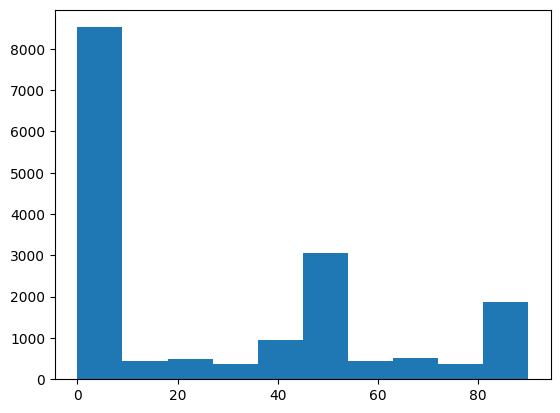

In [30]:
from matplotlib import pyplot as plt
gradient_magnitude2 = np.sqrt(np.square(img_hog_x) + np.square(img_hog_y))   #G=(Gx^2+Gy^2)^(1/2)
orientation = img_hog_y/img_hog_x
orientation = np.rad2deg(np.arctan(orientation)).ravel()                     #Angle=Tan^(-1)(Gy/Gx)
plt.hist(orientation)
plt.show()


<a id="toc"></a>

<a href="#toc" style="background-color: #E1B12D; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="5"></a>
## <b><span style='color:#E1B12D'>Simple Convoluted Neural Networks Implementation</span></b> 


In [31]:
#Installing MNIST Dataset module
!pip install mnist

Importing mnist data and displaying

2024-05-02 22:53:51.630968: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-02 22:53:51.631106: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-02 22:53:51.799632: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(60000,)


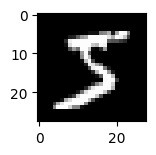

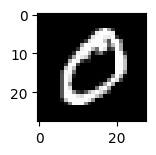

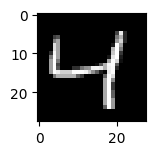

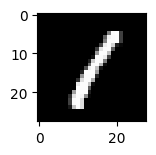

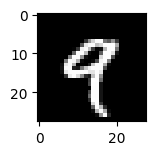

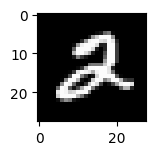

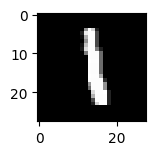

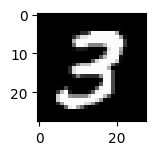

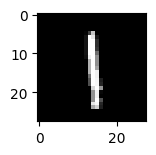

In [32]:
#Importing Libraries 
from tensorflow import keras
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

#loading data
(X_train,y_train) , (X_test,y_test)=mnist.load_data()

print(X_train.shape) # (60000, 28, 28)
print(y_train.shape) # (60000,)
for i in range(9):  
  plt.subplot(330 + 1 + i)
  plt.imshow(X_train[i], cmap=plt.get_cmap('gray'))   #Plotting images in grayscale
  plt.show()

Spliting in train and test 

In [33]:
# Normalize the images.
train_images = (X_train / 255) - 0.5
test_images = (X_test / 255) - 0.5

# Reshape the images.
train_images = np.expand_dims(train_images, axis=3)
test_images = np.expand_dims(test_images, axis=3)

print(train_images.shape) # (60000, 784)
print(test_images.shape)  # (10000, 784)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


Building model

In [34]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from keras.models import Sequential
num_filters = 8
filter_size = 3
pool_size = 2

#Here Model - Convolve --> Convolve --> MaxPool --> Flatten --> Dense by relu --> Dense by Softmax
model = Sequential([
  Conv2D(num_filters, filter_size, input_shape=(28, 28, 1)),
  Conv2D(num_filters, filter_size, input_shape=(28, 28, 1)),
  MaxPooling2D(pool_size=pool_size),
  Flatten(),
  Dense(100, activation='relu'),
  Dense(10, activation='softmax'),
])

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Compiling the model

In [35]:
model.compile(
  'adam',
  loss='categorical_crossentropy',
  metrics=['accuracy'],
)

Training the data

In [36]:
from tensorflow.keras.utils import to_categorical

model.fit(
  X_train,
  to_categorical(y_train),
  epochs=7,
  validation_data=(X_test, to_categorical(y_test)),
)

Epoch 1/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.8492 - loss: 2.6151 - val_accuracy: 0.9523 - val_loss: 0.1677
Epoch 2/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9576 - loss: 0.1499 - val_accuracy: 0.9649 - val_loss: 0.1264
Epoch 3/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9714 - loss: 0.0958 - val_accuracy: 0.9637 - val_loss: 0.1270
Epoch 4/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9763 - loss: 0.0787 - val_accuracy: 0.9692 - val_loss: 0.1114
Epoch 5/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9804 - loss: 0.0665 - val_accuracy: 0.9696 - val_loss: 0.1303
Epoch 6/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9825 - loss: 0.0611 - val_accuracy: 0.9747 - val_loss: 0.1170
Epoch 7/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9846 - loss: 0.0489 - val_accuracy: 0.9782 - val_loss: 0.1056


In [37]:
# Predict on the first 5 test images.
predictions = model.predict(test_images[:5])

# Print our model's predictions.
print(np.argmax(predictions, axis=1)) # [7, 2, 1, 0, 4]

# Check our predictions against the ground truths.
print(y_test[:5]) # [7, 2, 1, 0, 4]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[7 7 7 7 7]
[7 2 1 0 4]


In [38]:
#predicting all test data
Y_pred=model.predict(X_test)
Y_pred_=[]
for i in range(len(Y_pred)):
  Y_pred_.append(int(np.where(Y_pred[i]==Y_pred[i].max())[0]))
Y_pred_=np.array(Y_pred_)
Y_pred_.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


/tmp/ipykernel_18/747840516.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_pred_.append(int(np.where(Y_pred[i]==Y_pred[i].max())[0]))


(10000,)

In [39]:
#Making confusion matrix by comparinf presicted value and original value

from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(y_test, Y_pred_)

<Axes: >

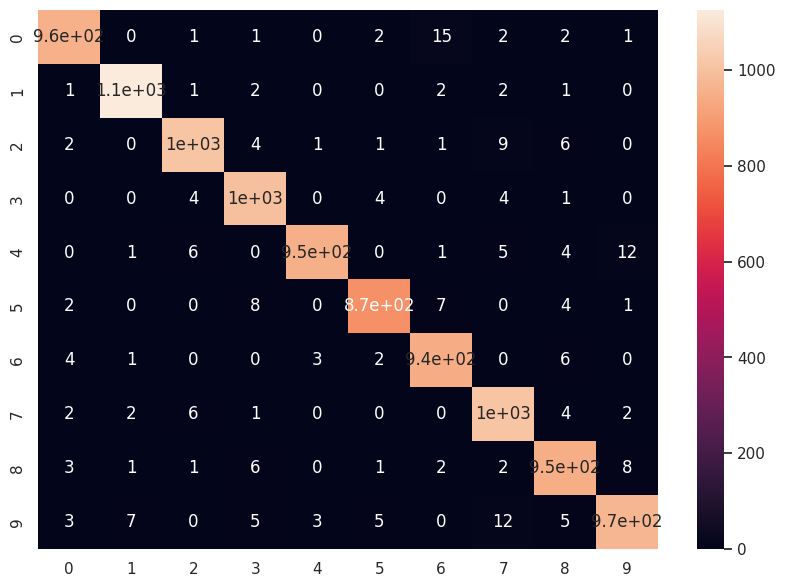

In [40]:
#Plotting heatmap of confusion matrix

import seaborn as sn
import pandas as pd
confusion_matrix = pd.DataFrame(confusion_matrix, range(10), range(10))
plt.figure(figsize=(10,7))
sn.set(font_scale=1) # for label size
sn.heatmap(confusion_matrix, annot=True) # font size

<a id="toc"></a>

<a href="#toc" style="background-color: #E1B12D; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="6"></a>
## <b><span style='color:#E1B12D'>Extracting audio features using Librosa</span></b> 


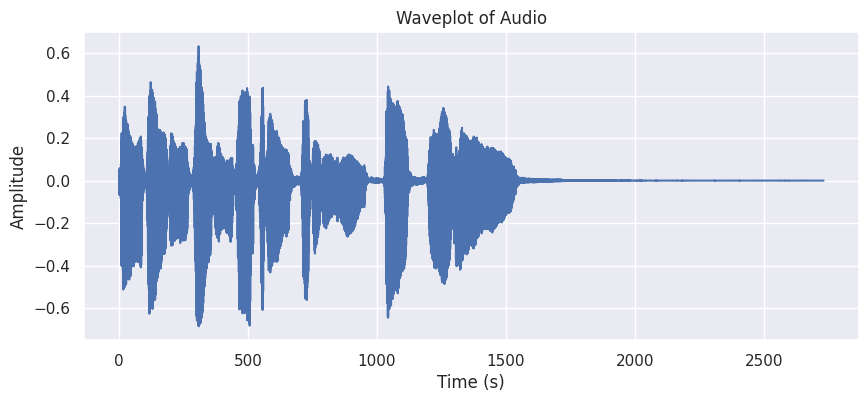

In [41]:
# Loading audio file and displaying its waveplot (amplitude-time)

import librosa
import librosa.display
import matplotlib.pyplot as plt

# Load the audio file
audio_path = librosa.ex('trumpet')
audio, sample_rate = librosa.load(audio_path)

# # Display the waveplot
# plt.figure(figsize=(10, 4))
# librosa.display.waveplot(audio, sr=sample_rate)
# plt.title('Waveplot of Audio')
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')
# plt.show()

# Create time axis in seconds
time = librosa.times_like(audio, sr=sample_rate)

# Display the waveplot
plt.figure(figsize=(10, 4))
plt.plot(time, audio)
plt.title('Waveplot of Audio')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()


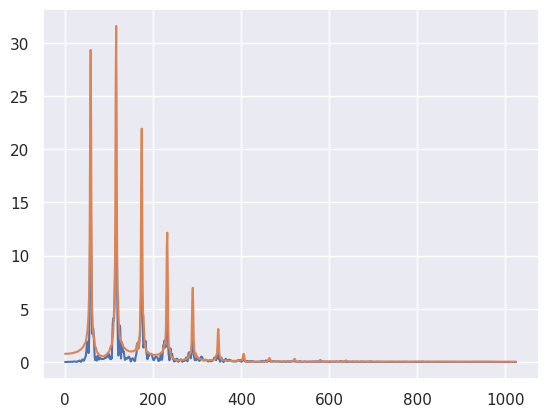

In [42]:
# Showing signal in frequency-time domain

import numpy as np
import matplotlib.pyplot as plt

# Compute STFT
ft = np.abs(librosa.stft(audio[:3000], hop_length = 3000)) 
plt.plot(ft);

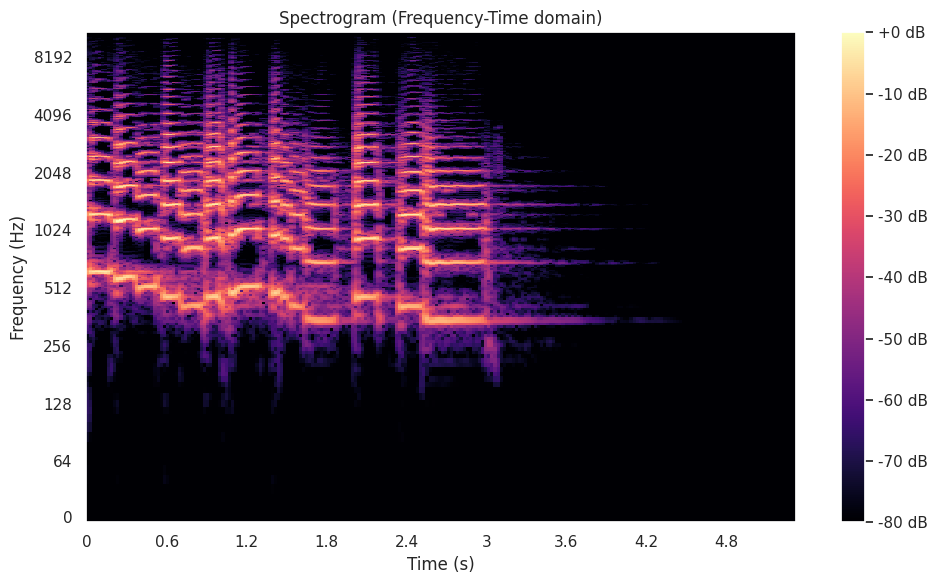

In [43]:
ft = np.abs(librosa.stft(audio, hop_length=512))

# Visualizing using Spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(librosa.amplitude_to_db(ft, ref=np.max), sr=sample_rate, hop_length=512, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (Frequency-Time domain)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

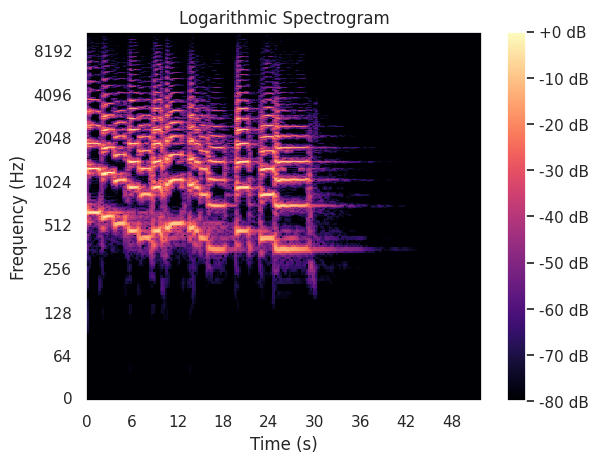

In [44]:
# Convert amplitude to decibels (dB)
ft_dB = librosa.amplitude_to_db(ft, ref=np.max)

# Plot the logarithmic spectrogram
librosa.display.specshow(ft_dB, sr=sample_rate, hop_length=5000, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Logarithmic Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

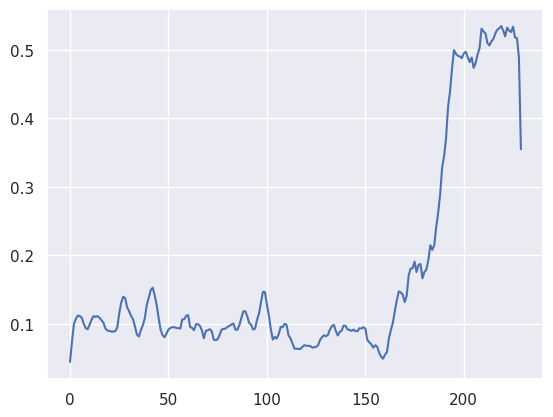

In [45]:
# Plotting zerocrossing

zero_crossings =librosa.feature.zero_crossing_rate(audio)
plt.plot(zero_crossings[0])

In [46]:
# Statistical features of Audio 
from scipy import stats
stats.describe(audio)

DescribeResult(nobs=117601, minmax=(-0.6847599, 0.63159853), mean=3.6692434e-08, variance=0.005866764174575512, skewness=-2.379090045906044, kurtosis=16.798001227706152)

<a id="toc"></a>

<a href="#toc" style="background-color: #E1B12D; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="7"></a>
## <b><span style='color:#E1B12D'>Implementation of Text Kernalization and Token Type Ratio (without library)</span></b> 


In [47]:
text='I find it recorded in my notebook that it was a bleak and windy day towards the end of March in the year 1892. Holmes had received a telegram while we sat at our lunch, and he had scribbled a reply. He made no remark, but the matter remained in his thoughts, for he stood in front of the fire afterwards with a thoughtful face, smoking his pipe, and casting an occasional glance at the message. Suddenly he turned upon me with a mischievous twinkle in his eyes. “I suppose, Watson, we must look upon you as a man of letters,” said he. “How do you define the word ‘grotesque’?” “Strange—remarkable,” I suggested. He shook his head at my definition. “There is surely something more than that,” said he; “some underlying suggestion of the tragic and the terrible. If you cast your mind back to some of those narratives with which you have afflicted a long-suffering public, you will recognize how often the grotesque has deepened into the criminal. Think of that little affair of the red-headed men. That was grotesque enough in the outset, and yet it ended in a desperate attempt at robbery. Or, again, there was that most grotesque affair of the five orange pips, which let straight to a murderous conspiracy. The word puts me on the alert.”'

In [48]:
#Finding unique words
unique_vals=list(set(text.split()))

#Making a dictionary of unique words with frequencies
dict_words={x:text.count(x) for x in unique_vals}

#Printing unique words with its frequency
print("Word","Frequency",sep="\t")
[print(x,dict_words[x],sep="\t") for x in dict_words]

#Calculating TTR = unique_vals/no of total words
print("TTR :",len(unique_vals)/len(text.split()))

Word	Frequency
it	8
attempt	1
shook	1
afterwards	1
back	1
into	1
remark,	1
straight	1
deepened	1
reply.	1
The	2
windy	1
He	2
define	1
pipe,	1
a	80
desperate	1
something	1
glance	1
suggestion	1
will	1
me	8
Or,	1
end	2
turned	1
orange	1
face,	1
outset,	1
thoughtful	1
Holmes	1
remained	1
no	3
those	1
tragic	1
Suddenly	1
conspiracy.	1
for	1
five	1
matter	1
must	1
your	1
1892.	1
mind	1
thoughts,	1
but	1
an	11
message.	1
twinkle	1
year	1
fire	1
the	15
enough	1
on	10
he;	1
Think	1
day	1
front	1
often	1
affair	2
March	1
grotesque	4
I	4
most	1
lunch,	1
some	3
than	1
is	6
and	5
bleak	1
again,	1
received	1
mischievous	1
‘grotesque’?”	1
while	1
find	1
murderous	1
suppose,	1
casting	1
towards	1
at	15
stood	1
cast	2
which	2
more	1
of	9
our	2
that	4
public,	1
in	23
that,”	1
little	1
word	2
ended	1
notebook	1
occasional	1
sat	1
“How	1
suggested.	1
how	1
upon	2
to	5
my	2
his	4
had	2
“I	1
let	2
robbery.	1
men.	1
he	24
terrible.	1
underlying	1
letters,”	1
“Strange—remarkable,”	1
there	1
“some	1
Watson,	1

<a id="toc"></a>

<a href="#toc" style="background-color: #E1B12D; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="8"></a>
## <b><span style='color:#E1B12D'>Extracting text features using NLTK</span></b> 


In [49]:
text='I find it recorded in my notebook that it was a bleak and windy day towards the end of March in the year 1892. Holmes had received a telegram while we sat at our lunch, and he had scribbled a reply. He made no remark, but the matter remained in his thoughts, for he stood in front of the fire afterwards with a thoughtful face, smoking his pipe, and casting an occasional glance at the message. Suddenly he turned upon me with a mischievous twinkle in his eyes. “I suppose, Watson, we must look upon you as a man of letters,” said he. “How do you define the word ‘grotesque’?” “Strange—remarkable,” I suggested. He shook his head at my definition. “There is surely something more than that,” said he; “some underlying suggestion of the tragic and the terrible. If you cast your mind back to some of those narratives with which you have afflicted a long-suffering public, you will recognize how often the grotesque has deepened into the criminal. Think of that little affair of the red-headed men. That was grotesque enough in the outset, and yet it ended in a desperate attempt at robbery. Or, again, there was that most grotesque affair of the five orange pips, which let straight to a murderous conspiracy. The word puts me on the alert.”'
text=text.lower()

In [50]:
# Importing and downloading necessary packages
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [51]:
# Tokenizing text
word_tokens = word_tokenize(text)  
print(word_tokens)
print(len(word_tokens))

['i', 'find', 'it', 'recorded', 'in', 'my', 'notebook', 'that', 'it', 'was', 'a', 'bleak', 'and', 'windy', 'day', 'towards', 'the', 'end', 'of', 'march', 'in', 'the', 'year', '1892.', 'holmes', 'had', 'received', 'a', 'telegram', 'while', 'we', 'sat', 'at', 'our', 'lunch', ',', 'and', 'he', 'had', 'scribbled', 'a', 'reply', '.', 'he', 'made', 'no', 'remark', ',', 'but', 'the', 'matter', 'remained', 'in', 'his', 'thoughts', ',', 'for', 'he', 'stood', 'in', 'front', 'of', 'the', 'fire', 'afterwards', 'with', 'a', 'thoughtful', 'face', ',', 'smoking', 'his', 'pipe', ',', 'and', 'casting', 'an', 'occasional', 'glance', 'at', 'the', 'message', '.', 'suddenly', 'he', 'turned', 'upon', 'me', 'with', 'a', 'mischievous', 'twinkle', 'in', 'his', 'eyes', '.', '“', 'i', 'suppose', ',', 'watson', ',', 'we', 'must', 'look', 'upon', 'you', 'as', 'a', 'man', 'of', 'letters', ',', '”', 'said', 'he', '.', '“', 'how', 'do', 'you', 'define', 'the', 'word', '‘', 'grotesque', '’', '?', '”', '“', 'strange—re

In [52]:
# Removing stop words
stop_words = set(stopwords.words('english'))
filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
print(filtered_sentence)
print(len(filtered_sentence))

['find', 'recorded', 'notebook', 'bleak', 'windy', 'day', 'towards', 'end', 'march', 'year', '1892.', 'holmes', 'received', 'telegram', 'sat', 'lunch', ',', 'scribbled', 'reply', '.', 'made', 'remark', ',', 'matter', 'remained', 'thoughts', ',', 'stood', 'front', 'fire', 'afterwards', 'thoughtful', 'face', ',', 'smoking', 'pipe', ',', 'casting', 'occasional', 'glance', 'message', '.', 'suddenly', 'turned', 'upon', 'mischievous', 'twinkle', 'eyes', '.', '“', 'suppose', ',', 'watson', ',', 'must', 'look', 'upon', 'man', 'letters', ',', '”', 'said', '.', '“', 'define', 'word', '‘', 'grotesque', '’', '?', '”', '“', 'strange—remarkable', ',', '”', 'suggested', '.', 'shook', 'head', 'definition', '.', '“', 'surely', 'something', ',', '”', 'said', ';', '“', 'underlying', 'suggestion', 'tragic', 'terrible', '.', 'cast', 'mind', 'back', 'narratives', 'afflicted', 'long-suffering', 'public', ',', 'recognize', 'often', 'grotesque', 'deepened', 'criminal', '.', 'think', 'little', 'affair', 'red-he

In [53]:
# Sentence Segmentation
sentences=nltk.sent_tokenize(text)
[print(x) for x in sentences]

i find it recorded in my notebook that it was a bleak and windy day towards the end of march in the year 1892. holmes had received a telegram while we sat at our lunch, and he had scribbled a reply.
he made no remark, but the matter remained in his thoughts, for he stood in front of the fire afterwards with a thoughtful face, smoking his pipe, and casting an occasional glance at the message.
suddenly he turned upon me with a mischievous twinkle in his eyes.
“i suppose, watson, we must look upon you as a man of letters,” said he.
“how do you define the word ‘grotesque’?” “strange—remarkable,” i suggested.
he shook his head at my definition.
“there is surely something more than that,” said he; “some underlying suggestion of the tragic and the terrible.
if you cast your mind back to some of those narratives with which you have afflicted a long-suffering public, you will recognize how often the grotesque has deepened into the criminal.
think of that little affair of the red-headed men.
tha

[None, None, None, None, None, None, None, None, None, None, None, None]

In [54]:
# Bag of words

import re
import pandas as pd

for i in range(len(sentences)):
    sentences[i] = re.sub(r'\W', ' ', sentences[i])      #Remove all non-word characters
    sentences[i] = re.sub(r'\s+', ' ', sentences[i])     #Remove all punctuations

X = []
for data in sentences:
  vector = []
  l=nltk.word_tokenize(data)
  for word in word_tokens:
    vector.append(l.count(word))    #Making list of the frequency of all unique words in each senetence
  X.append(vector)
X = pd.DataFrame(X)
X_names=X.copy()
X_names.columns=word_tokens
X_names                   #Shows frequency of words rather than 0 or 1 (presence/absence)

,i,find,it,recorded,in,my,notebook,that,it,was,...,.,the,word,puts,me,on,the,alert,.,”
0,1,1,2,1,2,1,1,1,2,1,...,0,2,0,0,0,0,2,0,0,0
1,0,0,0,0,2,0,0,0,0,0,...,0,3,0,0,0,0,3,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,1,0,0,0
5,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,1,0,0,...,0,2,0,0,0,0,2,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,2,0,0,0
8,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,1,0,0,0
9,0,0,1,0,2,0,0,1,1,1,...,0,1,0,0,0,0,1,0,0,0


In [55]:
X.style.apply(lambda x: ["background: green" if v > x.iloc[0] else "background: red" for v in x], axis = 1)
